# 02b — Prompt Variance

Systematic evaluation of how prompt design affects GPT-5.4 credit risk predictions.
Mirrors the same three-phase rigour used in model selection (01a/01b/01c).

**Fixed across all phases:** model (GPT-5.4 via OpenAI), no borrower description, same evaluation metrics  
**Varied:** system prompt framing and user prompt structure

---

## Structure

| Phase | Equivalent | What it does |
|-------|------------|--------------|
| 1 — Comparison | 01a | Run all 6 prompt variants on the 100-loan sample; pick the best |
| 2 — Consistency | 01b | Run the winning variant 3× on the same sample; measure stability |
| 3 — Robustness | 01c | Run the winning variant on a new held-out batch; check generalisation |

## Prompt variants tested in Phase 1

> **Baseline is not re-run here.** The default prompt (no description) is identical to
> **01a GPT-5.4 no_desc** — compare the variants below against that existing result
> rather than spending API budget to reproduce it.

| # | Name | What changes |
|---|------|--------------|
| 0 | `conservative` | Role reframed as risk-averse underwriter; bias toward flagging defaults |
| 1 | `chain_of_thought` | Step-by-step reasoning through risk factors before predicting |
| 2 | `few_shot` | 4 labeled training examples prepended to each user prompt |
| 3 | `top_features_only` | Only the 8 most important features (by XGBoost importance) passed in |
| 4 | `structured_4factor` | Explicit 4-factor evaluation framework in system prompt |
| 5 | `risk_signal_guide` | Expert prompt: 7 ranked risk signals w/ empirical thresholds (Jad's; false 'balanced ~50%' claim removed) |

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

from llm_utils import (
    load_llm_sample,
    run_llm_experiment,
    evaluate_predictions,
    build_system_prompt,
    build_user_prompt,
    build_few_shot_examples,
    format_loan_features,
    FEATURE_DESCRIPTIONS,
    top_xgb_features,
    load_api_key,
    RESULTS_DIR,
)

# ── Model config — change these 3 lines to switch provider ───────────────
API_PROVIDER       = 'openai'
MODEL_NAME         = 'gpt-5.4'
MODEL_LABEL        = 'GPT-5.4'
N_CONSISTENCY_RUNS = 3

# Load OpenAI API keys from .env for key-rotation and parallel execution
load_api_key("openai")
_key1 = os.environ.get("OPENAI_API_KEY")
_key2 = os.environ.get("OPENAI_API_KEY_2") or _key1
_key3 = os.environ.get("OPENAI_API_KEY_3") or _key1

API_KEYS = [_key1, _key2, _key3]
API_KEYS = [k for k in API_KEYS if k]
n_keys = len(set(API_KEYS))

# ── Derived settings ──────────────────────────────────────────────────────
# Since we are using OpenAI GPT-5.4, we run in standard per-loan mode to collect logprobs.
_SUPPORTS_LOGPROBS = True

print(f"Provider : {API_PROVIDER} / {MODEL_NAME}")
print(f"Logprobs : enabled (AUC will be computed)")
print(f"Parallel : yes ({n_keys} unique key(s) loaded for ThreadPoolExecutor key-rotation)")

Provider : openai / gpt-5.4
Logprobs : enabled (AUC will be computed)
Parallel : yes (3 unique key(s) loaded for ThreadPoolExecutor key-rotation)


## Define Prompt Variants

In [2]:
# Top-8 features by XGBoost importance, derived LIVE from the model — never
# hard-coded, since the feature set changed when FICO etc. were added.
TOP_FEATURES = top_xgb_features(n=8)
print(f'top_features_only uses (dynamic from XGBoost): {TOP_FEATURES}')

def format_top_features(row):
    lines = []
    for feat in TOP_FEATURES:
        if feat in row and pd.notna(row[feat]):
            label = FEATURE_DESCRIPTIONS.get(feat, feat)
            lines.append(f"- {label}: {row[feat]}")
    return "\n".join(lines)

_JSON_INSTRUCTION = (
    "\n\nRespond ONLY with valid JSON in this exact format:\n"
    '{"prediction": <1 or 0>, "reasoning": "<brief explanation>"}\n\n'
    "Where:\n"
    "- prediction: 1 = Fully Paid, 0 = Charged Off\n"
    "- reasoning: 1-2 sentence explanation of your prediction"
)

PROMPT_VARIANTS = [
    {
        "name": "conservative",
        "description": "Risk-averse underwriter; bias toward flagging defaults when uncertain",
        "system_prompt": (
            "You are a risk-averse credit underwriter at a bank. "
            "Your primary responsibility is protecting the institution from loan defaults. "
            "When the evidence is mixed or uncertain, err on the side of caution and predict Charged Off. "
            "Given a loan application's features, predict whether the borrower will fully repay or default."
            + _JSON_INSTRUCTION
        ),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },
    {
        "name": "chain_of_thought",
        "description": "Explicit step-by-step reasoning through risk factors before prediction",
        "system_prompt": (
            "You are a credit risk analyst. "
            "Before predicting loan outcomes, reason step by step through the evidence. "
            "Identify the key risk signals, weigh them against protective factors, "
            "then arrive at a final prediction."
            + _JSON_INSTRUCTION.replace(
                "1-2 sentence explanation of your prediction",
                "step-by-step analysis: risk signals, protective factors, and conclusion"
            )
        ),
        "user_prompt_fn": lambda row: (
            "Analyze this loan step by step and predict its outcome:\n\n"
            + format_loan_features(row, include_desc=False)
        ),
    },
    {
        "name": "few_shot",
        "description": "4 labeled training examples prepended before each prediction request",
        "system_prompt": build_system_prompt(),
        "user_prompt_fn": None,  # set below — skipped if raw CSV unavailable
    },
    {
        "name": "top_features_only",
        "description": "Only the 8 most important features by XGBoost importance are passed in",
        "system_prompt": build_system_prompt(),
        "user_prompt_fn": lambda row: (
            "Predict the outcome for this loan application (key features only):\n\n"
            + format_top_features(row)
        ),
    },
    {
        "name": "structured_4factor",
        "description": "Explicit 4-factor evaluation framework in the system prompt",
        "system_prompt": (
            "You are a credit risk analyst. "
            "Evaluate loans using this 4-factor framework:\n"
            "1. Income & Repayment Capacity: annual income vs. monthly installment burden\n"
            "2. Debt Burden: DTI ratio, revolving utilization rate\n"
            "3. Credit History: account age, derogatory public records, bankruptcies\n"
            "4. Loan Characteristics: grade, sub-grade, purpose, term, amount\n\n"
            "Apply this framework systematically to predict whether a loan will be Fully Paid or Charged Off."
            + _JSON_INSTRUCTION
        ),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },
    {
        "name": "risk_signal_guide",
        "description": "Expert prompt: 7 ranked risk signals with empirical thresholds (Jad's; false 'balanced ~50%' claim removed)",
        "system_prompt": (
            "You are a senior credit risk analyst specialising in peer-to-peer consumer lending. "
            "You are evaluating LendingClub loan applications (2012-2014 vintage) and must predict "
            "whether the borrower will be Fully Paid (1) or Charged Off (0).\n\n"
            "Key risk signals - weigh in order of importance:\n"
            "1. Grade / sub-grade: LendingClub's risk rating (A1 = safest, G5 = riskiest). "
            "Grades E-G historically default at >30%; A-B at <7%.\n"
            "2. Interest rate: direct proxy for perceived risk; >18% signals high-risk borrowers.\n"
            "3. Debt-to-income ratio (DTI): >25% indicates repayment stress; >35% is a strong default signal.\n"
            "4. Revolving utilisation: >80% suggests credit dependency and near-limit borrowing.\n"
            "5. Loan purpose: medical, small_business, moving have elevated default rates; "
            "debt_consolidation and credit_card are lower risk.\n"
            "6. Income verification: unverified high incomes are less reliable.\n"
            "7. Derogatory records: any public record or bankruptcy is a strong negative signal.\n\n"
            "Do NOT reflexively predict Fully Paid - genuinely assess each case on its merits."
            + _JSON_INSTRUCTION
        ),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },
]

# few_shot needs the raw CSV — skip gracefully if unavailable
try:
    print("Building few-shot examples from training set...")
    few_shot_text = build_few_shot_examples(n_examples=4, random_state=42)
    PROMPT_VARIANTS[3]["user_prompt_fn"] = lambda row: (
        "Here are examples of past loan outcomes:\n\n"
        + few_shot_text
        + "\nNow predict the outcome for this new loan application:\n\n"
        + format_loan_features(row, include_desc=False)
    )
    print("few_shot variant ready.")
except FileNotFoundError:
    print("WARNING: raw CSV not found — skipping few_shot variant.")
    PROMPT_VARIANTS = [v for v in PROMPT_VARIANTS if v["name"] != "few_shot"]

print(f"\n{len(PROMPT_VARIANTS)} prompt variants active:")
for v in PROMPT_VARIANTS:
    print(f"  [{v['name']}] {v['description']}")

top_features_only uses (dynamic from XGBoost): ['term', 'int_rate', 'sub_grade', 'purpose', 'fico_range_low', 'acc_open_past_24mths', 'home_ownership', 'annual_inc']
Building few-shot examples from training set...
few_shot variant ready.

6 prompt variants active:
  [conservative] Risk-averse underwriter; bias toward flagging defaults when uncertain
  [chain_of_thought] Explicit step-by-step reasoning through risk factors before prediction
  [few_shot] 4 labeled training examples prepended before each prediction request
  [top_features_only] Only the 8 most important features by XGBoost importance are passed in
  [structured_4factor] Explicit 4-factor evaluation framework in the system prompt
  [risk_signal_guide] Expert prompt: 7 ranked risk signals with empirical thresholds (Jad's; false 'balanced ~50%' claim removed)


## Load Data & XGBoost Baseline

In [3]:
llm_sample = load_llm_sample()
y_true = llm_sample['loan_status'].values

print(f'Sample: {len(llm_sample)} loans | '
      f'Fully Paid: {(y_true==1).sum()} | Charged Off: {(y_true==0).sum()}')


Sample: 100 loans | Fully Paid: 85 | Charged Off: 15


---
## Phase 1 — Comparison
*Which prompt variant performs best on the 100-loan evaluation sample?*

All variants use **GPT-5.4 via OpenAI**, no borrower description. Experiments run sequentially.

In [4]:
phase1_results = {}
phase1_failed  = []

def run_one_variant(idx, variant):
    name = variant["name"]
    key = API_KEYS[idx % len(API_KEYS)]
    print(f"Starting {name} on key {idx % len(API_KEYS) + 1}...")
    return run_llm_experiment(
        llm_sample,
        api_provider=API_PROVIDER,
        model_name=MODEL_NAME,
        include_desc=False,
        api_key=key,
        label=f"{MODEL_LABEL} | {name}",
        with_logprobs=_SUPPORTS_LOGPROBS,
        system_prompt=variant["system_prompt"],
        user_prompt_fn=variant["user_prompt_fn"],
    )

max_workers = min(len(API_KEYS), len(PROMPT_VARIANTS))
print(f"Launching {len(PROMPT_VARIANTS)} prompt variants in parallel (max_workers={max_workers})...\n")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(run_one_variant, i, var): var["name"]
        for i, var in enumerate(PROMPT_VARIANTS)
    }
    for fut in as_completed(futures):
        name = futures[fut]
        try:
            res = fut.result()
            phase1_results[name] = res
            print(f"SUCCESS: {name}")
        except Exception as e:
            print(f"*** FAILED [{name}]: {e} ***")
            phase1_failed.append((name, str(e)))

print(f"\nPhase 1 done: {len(phase1_results)} succeeded, {len(phase1_failed)} failed")

Launching 6 prompt variants in parallel (max_workers=3)...

Starting conservative on key 1...
Starting chain_of_thought on key 2...
Starting few_shot on key 3...
[GPT-5.4 | conservative | no_desc] First call OK (pred=1, prob=1.0). Starting full run...
[GPT-5.4 | few_shot | no_desc] First call OK (pred=1, prob=1.0). Starting full run...
[GPT-5.4 | chain_of_thought | no_desc] First call OK (pred=1, prob=1.0). Starting full run...
[GPT-5.4 | few_shot | no_desc] 10/100 done (22s elapsed, ~201s remaining)
[GPT-5.4 | conservative | no_desc] 10/100 done (23s elapsed, ~208s remaining)
[GPT-5.4 | chain_of_thought | no_desc] 10/100 done (43s elapsed, ~384s remaining)
[GPT-5.4 | few_shot | no_desc] 20/100 done (45s elapsed, ~181s remaining)
[GPT-5.4 | conservative | no_desc] 20/100 done (48s elapsed, ~192s remaining)
[GPT-5.4 | few_shot | no_desc] 30/100 done (68s elapsed, ~158s remaining)
[GPT-5.4 | conservative | no_desc] 30/100 done (71s elapsed, ~165s remaining)
[GPT-5.4 | chain_of_thought | 

In [5]:
p1_rows = []
for v in PROMPT_VARIANTS:
    name = v['name']
    if name in phase1_results:
        p1_rows.append({'variant': name, 'description': v['description'], **phase1_results[name]['metrics']})

phase1_summary = pd.DataFrame(p1_rows).set_index('variant')
display_cols = ['accuracy', 'auc', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off', 'n_valid']
print(phase1_summary[display_cols].to_string(float_format='{:.3f}'.format))


                    accuracy   auc  precision_charged_off  recall_charged_off  f1_charged_off  n_valid
variant                                                                                               
conservative           0.540 0.620                  0.196               0.667           0.303      100
chain_of_thought       0.830 0.645                  0.417               0.333           0.370      100
few_shot               0.820 0.637                  0.385               0.333           0.357      100
top_features_only      0.680 0.632                  0.226               0.467           0.304      100
structured_4factor     0.780 0.613                  0.316               0.400           0.353      100
risk_signal_guide      0.750 0.635                  0.273               0.400           0.324      100


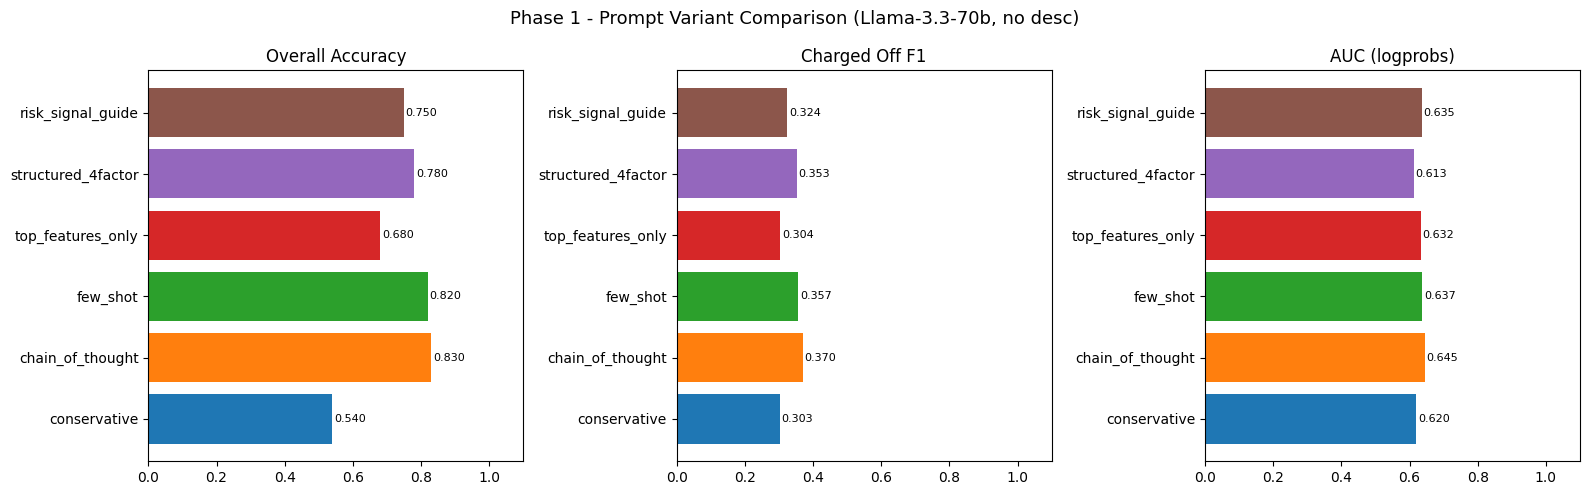

In [6]:
plot_df = phase1_summary.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 1 - Prompt Variant Comparison (Llama-3.3-70b, no desc)', fontsize=13)
colors = plt.cm.tab10.colors

for ax, (metric, title) in zip(axes, [
    ('accuracy',       'Overall Accuracy'),
    ('f1_charged_off', 'Charged Off F1'),
    ('auc',            'AUC (logprobs)'),
]):
    vals = plot_df[metric].apply(
        lambda x: 0.0 if (x is None or (isinstance(x, float) and np.isnan(x))) else float(x)
    )
    bars = ax.barh(plot_df['variant'], vals, color=colors[:len(plot_df)])
    for bar, val in zip(bars, plot_df[metric]):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlim(0, 1.1)

plt.tight_layout()
plt.show()

In [7]:
# Winner = highest Charged Off F1 (the metric that matters most for credit risk)
winner_name = max(
    phase1_results,
    key=lambda name: phase1_results[name]["metrics"]["f1_charged_off"] or 0
)
winner_variant = next(v for v in PROMPT_VARIANTS if v["name"] == winner_name)

print(f"Winner: [{winner_name}]")
print(f"Description: {winner_variant['description']}")
print(f"Charged Off F1: {phase1_results[winner_name]['metrics']['f1_charged_off']:.3f}")
print(f"Accuracy:       {phase1_results[winner_name]['metrics']['accuracy']:.3f}")
print(f"\nThis variant will be used for Phase 2 (consistency) and Phase 3 (robustness).")

Winner: [chain_of_thought]
Description: Explicit step-by-step reasoning through risk factors before prediction
Charged Off F1: 0.370
Accuracy:       0.830

This variant will be used for Phase 2 (consistency) and Phase 3 (robustness).


---
## Phase 2 — Consistency
*Is the winning prompt stable, or does it flip predictions between runs?*

Same 100-loan sample, same winning prompt, run 3 times. We measure per-loan flip rate and metric variance across runs.

In [ ]:
phase2_runs = []

def run_one_consistency(run_i):
    key = API_KEYS[(run_i - 1) % len(API_KEYS)]
    print(f"Starting consistency run {run_i} on key {(run_i - 1) % len(API_KEYS) + 1}...")
    return run_llm_experiment(
        llm_sample,
        api_provider=API_PROVIDER,
        model_name=MODEL_NAME,
        include_desc=False,
        api_key=key,
        label=f"{MODEL_LABEL} | {winner_name} | run{run_i}",
        with_logprobs=_SUPPORTS_LOGPROBS,
        system_prompt=winner_variant["system_prompt"],
        user_prompt_fn=winner_variant["user_prompt_fn"],
    )

max_workers = min(len(API_KEYS), N_CONSISTENCY_RUNS)
print(f"Launching {N_CONSISTENCY_RUNS} consistency runs in parallel (max_workers={max_workers})...\n")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = [executor.submit(run_one_consistency, i) for i in range(1, N_CONSISTENCY_RUNS + 1)]
    for fut in as_completed(futures):
        try:
            res = fut.result()
            phase2_runs.append(res)
        except Exception as e:
            print(f"*** Consistency Run FAILED: {e} ***")

# Sort phase2_runs by run index to keep it ordered
phase2_runs = sorted(phase2_runs, key=lambda r: int(r['label'].split('run')[-1]))
print(f"\nPhase 2 done: {len(phase2_runs)} runs completed successfully")

Launching 3 consistency runs in parallel (max_workers=3)...

Starting consistency run 1 on key 1...
Starting consistency run 2 on key 2...
Starting consistency run 3 on key 3...
[GPT-5.4 | chain_of_thought | run2 | no_desc] First call OK (pred=1, prob=1.0). Starting full run...
[GPT-5.4 | chain_of_thought | run3 | no_desc] First call OK (pred=1, prob=1.0). Starting full run...
[GPT-5.4 | chain_of_thought | run1 | no_desc] First call OK (pred=1, prob=1.0). Starting full run...
[GPT-5.4 | chain_of_thought | run2 | no_desc] 10/100 done (35s elapsed, ~312s remaining)
[GPT-5.4 | chain_of_thought | run1 | no_desc] 10/100 done (35s elapsed, ~319s remaining)
[GPT-5.4 | chain_of_thought | run3 | no_desc] 10/100 done (37s elapsed, ~329s remaining)
[GPT-5.4 | chain_of_thought | run2 | no_desc] 20/100 done (73s elapsed, ~294s remaining)
[GPT-5.4 | chain_of_thought | run3 | no_desc] 20/100 done (75s elapsed, ~302s remaining)
[GPT-5.4 | chain_of_thought | run1 | no_desc] 20/100 done (78s elapsed, ~3

In [ ]:
# Per-run metrics
p2_metrics = pd.DataFrame([
    {"run": i + 1, **r["metrics"]}
    for i, r in enumerate(phase2_runs)
]).set_index("run")

print("Per-run metrics:")
print(p2_metrics[["accuracy", "auc", "f1_charged_off"]].to_string(float_format="{:.3f}".format))

print(f"\nMean accuracy:        {p2_metrics['accuracy'].mean():.3f}  (std {p2_metrics['accuracy'].std():.3f})")
print(f"Mean Charged Off F1:  {p2_metrics['f1_charged_off'].mean():.3f}  (std {p2_metrics['f1_charged_off'].std():.3f})")
auc_vals = p2_metrics['auc'].dropna()
if len(auc_vals):
    print(f"Mean AUC:             {auc_vals.mean():.3f}  (std {auc_vals.std():.3f})")

# Per-loan stability: fraction of loans where ALL runs agree
all_preds = np.array([r["predictions"] for r in phase2_runs])
per_loan_stable = np.apply_along_axis(lambda col: len(set(col)) == 1, 0, all_preds)
print(f"\nPer-loan stability (all {N_CONSISTENCY_RUNS} runs agree): "
      f"{per_loan_stable.sum()}/100 ({per_loan_stable.mean()*100:.1f}%)")

# Which loans flipped?
flip_indices = np.where(~per_loan_stable)[0]
if len(flip_indices):
    print(f"Loans that flipped at least once: indices {list(flip_indices)}")
    flip_df = pd.DataFrame({
        "loan_index": flip_indices,
        "actual": y_true[flip_indices],
        **{f"run{i+1}": all_preds[i][flip_indices] for i in range(N_CONSISTENCY_RUNS)},
    })
    print(flip_df.to_string(index=False))
else:
    print("No loans flipped across runs — fully stable.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Phase 2b - Consistency ({N_CONSISTENCY_RUNS} runs, winner: {winner_name})', fontsize=12)

runs = [f'Run {i}' for i in p2_metrics.index]

axes[0].bar(runs, p2_metrics['accuracy'], color='steelblue', alpha=0.8)
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy per run')
for i, v in enumerate(p2_metrics['accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(runs, p2_metrics['f1_charged_off'], color='coral', alpha=0.8)
axes[1].set_ylim(0, 1)
axes[1].set_title('Charged Off F1 per run')
for i, v in enumerate(p2_metrics['f1_charged_off']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


---
## Phase 3 — Robustness
*Does the winning prompt generalise to new, unseen loans?*

A fresh 100-loan batch is sampled from the held-out test set (excluding loans already in the evaluation sample). The winning prompt is run once on this new batch.

In [ ]:
from sample_generation import get_robustness_batch

# Phase 3 robustness uses the same held-out robustness batch as 01c.
new_batch = get_robustness_batch()
y_true_new = new_batch['loan_status'].values
print(f'Robustness batch: {len(new_batch)} loans | '
      f'Fully Paid: {(y_true_new==1).sum()} | Charged Off: {(y_true_new==0).sum()}')

In [ ]:
print(f"Running [{winner_name}] on new batch...")
phase3_result = run_llm_experiment(
    new_batch,
    api_provider=API_PROVIDER,
    model_name=MODEL_NAME,
    include_desc=False,
    label=f"{MODEL_LABEL} | {winner_name} | new batch",
            with_logprobs=_SUPPORTS_LOGPROBS,
    system_prompt=winner_variant["system_prompt"],
    user_prompt_fn=winner_variant["user_prompt_fn"],
)

In [ ]:
p1_winner_metrics = phase1_results[winner_name]['metrics']
p3_metrics = phase3_result['metrics']

robustness_df = pd.DataFrame([
    {'split': 'Original sample (Phase 1)', **p1_winner_metrics},
    {'split': 'New batch (Phase 3)',       **p3_metrics},
]).set_index('split')

display_cols = ['accuracy', 'auc', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off']
print('Robustness comparison:')
print(robustness_df[display_cols].to_string(float_format='{:.3f}'.format))

acc_drop = p1_winner_metrics['accuracy'] - p3_metrics['accuracy']
f1_drop  = p1_winner_metrics['f1_charged_off'] - p3_metrics['f1_charged_off']
print(f'\nPerformance drop (original -> new batch):')
print(f'  Accuracy:        {acc_drop:+.3f}')
print(f'  Charged Off F1:  {f1_drop:+.3f}')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Phase 3b - Robustness (winner: {winner_name})', fontsize=12)

groups = ['Original\nsample', 'New batch']
llm_acc = [p1_winner_metrics['accuracy'], p3_metrics['accuracy']]
llm_f1  = [p1_winner_metrics['f1_charged_off'], p3_metrics['f1_charged_off']]

x = np.arange(len(groups))
w = 0.5

for ax, (vals, title) in zip(axes, [
    (llm_acc, 'Overall Accuracy'),
    (llm_f1,  'Charged Off F1'),
]):
    bars = ax.bar(x, vals, w, label=f'Llama | {winner_name}', color='steelblue', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## Export Results

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Phase 1 - metrics
phase1_summary.to_csv(f'{RESULTS_DIR}/02b_phase1_metrics.csv')

# Per-loan predictions + reasonings
pred_rows = []
for v in PROMPT_VARIANTS:
    name = v['name']
    if name not in phase1_results:
        continue
    result = phase1_results[name]
    for i, (pred, prob, reasoning) in enumerate(
        zip(result['predictions'], result['probabilities'], result['reasonings'])
    ):
        pred_rows.append({
            'phase': 1, 'variant': name, 'loan_index': i,
            'actual': int(y_true[i]), 'prediction': pred,
            'correct': int(pred == y_true[i]) if pred is not None else None,
            'prob_fully_paid': prob, 'reasoning': reasoning,
        })

# Phase 2 - per-run predictions
for run_i, result in enumerate(phase2_runs, 1):
    for i, (pred, prob, reasoning) in enumerate(
        zip(result['predictions'], result['probabilities'], result['reasonings'])
    ):
        pred_rows.append({
            'phase': 2, 'variant': f'{winner_name}_run{run_i}', 'loan_index': i,
            'actual': int(y_true[i]), 'prediction': pred,
            'correct': int(pred == y_true[i]) if pred is not None else None,
            'prob_fully_paid': prob, 'reasoning': reasoning,
        })

# Phase 3 - new batch predictions
for i, (pred, prob, reasoning) in enumerate(
    zip(phase3_result['predictions'], phase3_result['probabilities'], phase3_result['reasonings'])
):
    pred_rows.append({
        'phase': 3, 'variant': f'{winner_name}_new_batch', 'loan_index': i,
        'actual': int(y_true_new[i]), 'prediction': pred,
        'correct': int(pred == y_true_new[i]) if pred is not None else None,
        'prob_fully_paid': prob, 'reasoning': reasoning,
    })

pd.DataFrame(pred_rows).to_csv(f'{RESULTS_DIR}/02b_predictions.csv', index=False)
p2_metrics.to_csv(f'{RESULTS_DIR}/02b_phase2_consistency.csv')
robustness_df[display_cols].to_csv(f'{RESULTS_DIR}/02b_phase3_robustness.csv')

with open(f'{RESULTS_DIR}/02b_reasonings.jsonl', 'w', encoding='utf-8') as f:
    for row in pred_rows:
        f.write(json.dumps(row) + '\n')

print('Saved:')
print(f'  02b_phase1_metrics.csv')
print(f'  02b_predictions.csv ({len(pred_rows)} rows)')
print(f'  02b_phase2_consistency.csv')
print(f'  02b_phase3_robustness.csv')
print(f'  02b_reasonings.jsonl  <- per-loan LLM reasonings (qualitative inspection)')
print(f'\nAll in: {RESULTS_DIR}')


---
## Phase 5 — Description Impact
*Does adding the borrower's written description improve the winning variant?*

Run the winner once more with `include_desc=True` so we can compare directly.

In [ ]:
phase5_results = {}
phase5_failed = []

def _make_desc_fn(base_fn):
    def _fn(row):
        base = base_fn(row)
        desc = row.get("desc", "")
        if desc and pd.notna(desc) and str(desc).strip():
            return base + f"\n\nBorrower's own description:\n{str(desc).strip()}"
        return base
    return _fn

def run_one_desc_variant(idx, variant):
    name = variant["name"]
    key = API_KEYS[idx % len(API_KEYS)]
    print(f"Starting {name} + desc on key {idx % len(API_KEYS) + 1}...")
    return run_llm_experiment(
        llm_sample,
        api_provider=API_PROVIDER,
        model_name=MODEL_NAME,
        include_desc=True,
        api_key=key,
        label=f"{MODEL_LABEL} | {name} + desc",
        with_logprobs=_SUPPORTS_LOGPROBS,
        system_prompt=variant["system_prompt"],
        user_prompt_fn=_make_desc_fn(variant["user_prompt_fn"]),
    )

max_workers = min(len(API_KEYS), len(PROMPT_VARIANTS))
print(f"Launching {len(PROMPT_VARIANTS)} prompt variants with desc in parallel (max_workers={max_workers})...\n")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(run_one_desc_variant, i, var): var["name"]
        for i, var in enumerate(PROMPT_VARIANTS)
    }
    for fut in as_completed(futures):
        name = futures[fut]
        try:
            res = fut.result()
            phase5_results[name] = res
            m = res["metrics"]
            print(f"SUCCESS: {name} | Accuracy: {m['accuracy']:.3f} | Charged Off F1: {m['f1_charged_off']:.3f}")
        except Exception as e:
            print(f"*** FAILED [{name} + desc]: {e} ***")
            phase5_failed.append((name, str(e)))

print(f"\nPhase 5 done: {len(phase5_results)}/{len(PROMPT_VARIANTS)} succeeded")

In [ ]:
from IPython.display import display

comparison_rows = []

for v in PROMPT_VARIANTS:
    name = v["name"]
    # Without description (Phase 1)
    if name in phase1_results:
        m = phase1_results[name]["metrics"]
        comparison_rows.append({
            "variant": name,
            "description": v["description"],
            "with_desc": "No",
            "accuracy":              round(m["accuracy"], 3),
            "precision_charged_off": round(m["precision_charged_off"] or 0, 3),
            "recall_charged_off":    round(m["recall_charged_off"] or 0, 3),
            "f1_charged_off":        round(m["f1_charged_off"] or 0, 3),
            "n_valid":               m["n_valid"],
        })
    # With description (Phase 5)
    if name in phase5_results:
        m = phase5_results[name]["metrics"]
        comparison_rows.append({
            "variant": name,
            "description": v["description"],
            "with_desc": "Yes",
            "accuracy":              round(m["accuracy"], 3),
            "precision_charged_off": round(m["precision_charged_off"] or 0, 3),
            "recall_charged_off":    round(m["recall_charged_off"] or 0, 3),
            "f1_charged_off":        round(m["f1_charged_off"] or 0, 3),
            "n_valid":               m["n_valid"],
        })

comparison_df = pd.DataFrame(comparison_rows)
metric_cols = ["accuracy", "precision_charged_off", "recall_charged_off", "f1_charged_off", "n_valid"]

print("Full comparison — all variants × (no desc / with desc):\n")
display(
    comparison_df[["variant", "with_desc"] + metric_cols]
    .style
    .format({c: "{:.3f}" for c in metric_cols if c != "n_valid"})
    .highlight_max(subset=["accuracy", "f1_charged_off"], color="lightgreen", axis=0)
    .highlight_min(subset=["accuracy", "f1_charged_off"], color="#ffcccc", axis=0)
    .set_caption("Green = best · Red = worst")
)

comparison_df.to_csv(f"{RESULTS_DIR}/02b_full_comparison.csv", index=False)
print(f"\nSaved: {RESULTS_DIR}/02b_full_comparison.csv")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

variant_names = [v["name"] for v in PROMPT_VARIANTS]
x = np.arange(len(variant_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("All Variants — No Description vs. With Description", fontsize=13, fontweight="bold")

for ax, metric, title in zip(axes,
    ["accuracy", "f1_charged_off"],
    ["Overall Accuracy", "Charged Off F1"],
):
    no_desc  = [phase1_results[n]["metrics"][metric] or 0 if n in phase1_results else 0 for n in variant_names]
    with_desc = [phase5_results[n]["metrics"][metric] or 0 if n in phase5_results else 0 for n in variant_names]

    bars1 = ax.bar(x - w/2, no_desc,  w, label="No description",   color="#2196f3", alpha=0.85)
    bars2 = ax.bar(x + w/2, with_desc, w, label="With description", color="#f4a529", alpha=0.85)

    for bar, val in zip(bars1, no_desc):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f"{val:.3f}",
                ha="center", va="bottom", fontsize=7.5)
    for bar, val in zip(bars2, with_desc):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f"{val:.3f}",
                ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(variant_names, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontsize=11)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/02b_variant_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR}/02b_variant_comparison.png")